In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, f1_score, precision_score
from sklearn.impute import SimpleImputer

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_parquet('classification_ring/data/processed/data_ml.parquet')
print(df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(1452411, 38)


,pdb_id,s_ch,s_resi,s_ins,s_resn,s_ss8,s_rsa,s_phi,s_psi,s_a1,...,t_a5,t_3di_state,t_3di_letter,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
0,8ehe,A,491,,L,H,0.000,-1.291,-0.343,-1.019,...,-1.262,9.0,J,0,0,0,0,0,0,1
1,8ehe,A,310,,I,E,0.006,-1.753,2.013,-1.239,...,-0.146,6.0,G,0,0,0,0,0,0,1
2,8ehe,A,327,,Y,S,0.739,-1.969,-0.969,0.260,...,-0.837,17.0,R,1,0,0,0,0,0,0
3,8ehe,A,398,,G,-,0.000,1.962,2.766,-0.384,...,-1.853,5.0,F,1,0,0,0,0,0,1
4,8ehe,A,318,,W,E,0.137,-1.649,2.665,-0.595,...,1.512,6.0,G,0,0,0,0,1,0,0


In [2]:
pair_cols = [
    "pdb_id",
    "s_ch", "s_resi", "s_ins", "s_resn",
    "t_ch", "t_resi", "t_ins", "t_resn"
]

label_cols = ['HBOND', 'VDW', 'IONIC', 'PIPISTACK', 'PICATION', 'SSBOND', 'PIHBOND']

num_features = [
    's_rsa', 's_phi', 's_psi', 's_a1', 's_a2', 's_a3', 's_a4', 's_a5',
    's_3di_state',
    't_rsa', 't_phi', 't_psi', 't_a1', 't_a2', 't_a3', 't_a4', 't_a5',
    't_3di_state'
]

cat_features = [
    's_ss8', 's_3di_letter',
    't_ss8', 't_3di_letter'
]

feature_cols = num_features + cat_features

print("Label distribution:")
print(df[label_cols].sum().sort_values(ascending=False))

Label distribution:
HBOND        1055929
VDW           737061
PIPISTACK      38283
IONIC          35391
PICATION        8885
SSBOND          2100
PIHBOND         1790
dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

pdb_ids = df['pdb_id'].unique()
print(f"Total unique PDBs: {len(pdb_ids)}")

train_pdbs, temp_pdbs = train_test_split(pdb_ids, test_size=0.30, random_state=42)
val_pdbs, test_pdbs   = train_test_split(temp_pdbs, test_size=0.50, random_state=42)

train_df = df[df['pdb_id'].isin(train_pdbs)].reset_index(drop=True)
val_df   = df[df['pdb_id'].isin(val_pdbs)].reset_index(drop=True)
test_df  = df[df['pdb_id'].isin(test_pdbs)].reset_index(drop=True)

print(f"Train: {len(train_df)} rows, {len(train_pdbs)} PDBs")
print(f"Val:   {len(val_df)} rows, {len(val_pdbs)} PDBs")
print(f"Test:  {len(test_df)} rows, {len(test_pdbs)} PDBs")

Total unique PDBs: 3827
Train: 1041204 rows, 2678 PDBs
Val:   195035 rows, 574 PDBs
Test:  216172 rows, 575 PDBs


In [4]:
X_train = train_df[feature_cols].copy()
Y_train = train_df[label_cols].copy()

X_val = val_df[feature_cols].copy()
Y_val = val_df[label_cols].copy()

X_test = test_df[feature_cols].copy()
Y_test = test_df[label_cols].copy()

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

X_train shape: (1041204, 22)
Y_train shape: (1041204, 7)


In [5]:
#one-hot encode categorical features
X_train = pd.get_dummies(X_train, columns=cat_features)
X_val   = pd.get_dummies(X_val,   columns=cat_features)
X_test  = pd.get_dummies(X_test,  columns=cat_features)
X_train, X_val  = X_train.align(X_val,  join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_val   = pd.DataFrame(imputer.transform(X_val),       columns=X_val.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

print("X_train shape after encoding:", X_train.shape)

X_train shape after encoding: (1041204, 76)


In [9]:
rf = MultiOutputClassifier(
    xgb.XGBClassifier(
    n_estimators=150,        # Number of boosting rounds
    max_depth=6,             # Maximum tree depth
    learning_rate=0.1,       # Step size shrinkage
    tree_method='hist',      # Optimized training method for large tabular datasets
    random_state=42,
    n_jobs=-1                # Use all available CPU cores
)
)
rf.fit(X_train, Y_train)


MultiOutputClassifier(estimator=XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=None,
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=0.1, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=6,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=150, n_jobs=-1,
                                              num_parallel_tree=None, ...))

In [10]:
Y_pred = rf.predict(X_val)

print("=" * 60)
print("PER-CLASS RESULTS ON VALIDATION SET")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1 = f1_score(Y_val, Y_pred, average='macro', zero_division=0)
micro_f1 = f1_score(Y_val, Y_pred, average='micro', zero_division=0)
print(f"\nMacro F1: {macro_f1:.4f}")
print(f"Micro F1: {micro_f1:.4f}")

PER-CLASS RESULTS ON VALIDATION SET

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.70      0.28      0.40     54116
     present       0.78      0.95      0.86    140919

    accuracy                           0.77    195035
   macro avg       0.74      0.62      0.63    195035
weighted avg       0.76      0.77      0.73    195035


--- VDW ---
              precision    recall  f1-score   support

      absent       0.59      0.58      0.58     94949
     present       0.61      0.62      0.61    100086

    accuracy                           0.60    195035
   macro avg       0.60      0.60      0.60    195035
weighted avg       0.60      0.60      0.60    195035


--- IONIC ---
              precision    recall  f1-score   support

      absent       0.98      1.00      0.99    190589
     present       0.62      0.31      0.41      4446

    accuracy                           0.98    195035
   macro avg       0.80      0.65      0.70    19

In [11]:

Y_prob = rf.predict_proba(X_val)
Y_prob_present = np.column_stack([prob[:, 1] for prob in Y_prob])
thresholds = np.arange(0.1, 0.9, 0.05)

best_thresholds = {}

for i, label in enumerate(label_cols):
    best_f1 = 0
    best_t = 0.5
    for t in thresholds:
        y_pred_t = (Y_prob_present[:, i] >= t).astype(int)
        f1 = f1_score(Y_val.iloc[:, i], y_pred_t, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds[label] = best_t
    print(f"{label}: best threshold = {best_t:.2f}, F1 = {best_f1:.4f}")

print("\nBest thresholds:", best_thresholds)

HBOND: best threshold = 0.50, F1 = 0.8559
VDW: best threshold = 0.35, F1 = 0.6863
IONIC: best threshold = 0.25, F1 = 0.5612
PIPISTACK: best threshold = 0.50, F1 = 0.8525
PICATION: best threshold = 0.15, F1 = 0.4234
SSBOND: best threshold = 0.55, F1 = 0.9050
PIHBOND: best threshold = 0.10, F1 = 0.0767

Best thresholds: {'HBOND': np.float64(0.5000000000000001), 'VDW': np.float64(0.3500000000000001), 'IONIC': np.float64(0.25000000000000006), 'PIPISTACK': np.float64(0.5000000000000001), 'PICATION': np.float64(0.15000000000000002), 'SSBOND': np.float64(0.5500000000000002), 'PIHBOND': np.float64(0.1)}


In [12]:
print("=" * 60)
print("RESULTS WITH TUNED THRESHOLDS ON VALIDATION SET")
print("=" * 60)

Y_pred_tuned = np.column_stack([
    (Y_prob_present[:, i] >= best_thresholds[label]).astype(int)
    for i, label in enumerate(label_cols)
])

for i, label in enumerate(label_cols):
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val.iloc[:, i],
        Y_pred_tuned[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1_tuned = f1_score(Y_val, Y_pred_tuned, average='macro', zero_division=0)
micro_f1_tuned = f1_score(Y_val, Y_pred_tuned, average='micro', zero_division=0)
print(f"\nMacro F1 (tuned): {macro_f1_tuned:.4f}")
print(f"Micro F1 (tuned): {micro_f1_tuned:.4f}")

RESULTS WITH TUNED THRESHOLDS ON VALIDATION SET

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.70      0.28      0.40     54116
     present       0.78      0.95      0.86    140919

    accuracy                           0.77    195035
   macro avg       0.74      0.62      0.63    195035
weighted avg       0.76      0.77      0.73    195035


--- VDW ---
              precision    recall  f1-score   support

      absent       0.75      0.10      0.18     94949
     present       0.53      0.97      0.69    100086

    accuracy                           0.55    195035
   macro avg       0.64      0.53      0.43    195035
weighted avg       0.64      0.55      0.44    195035


--- IONIC ---
              precision    recall  f1-score   support

      absent       1.00      0.98      0.99    190589
     present       0.43      0.80      0.56      4446

    accuracy                           0.97    195035
   macro avg       0.71      0.89    

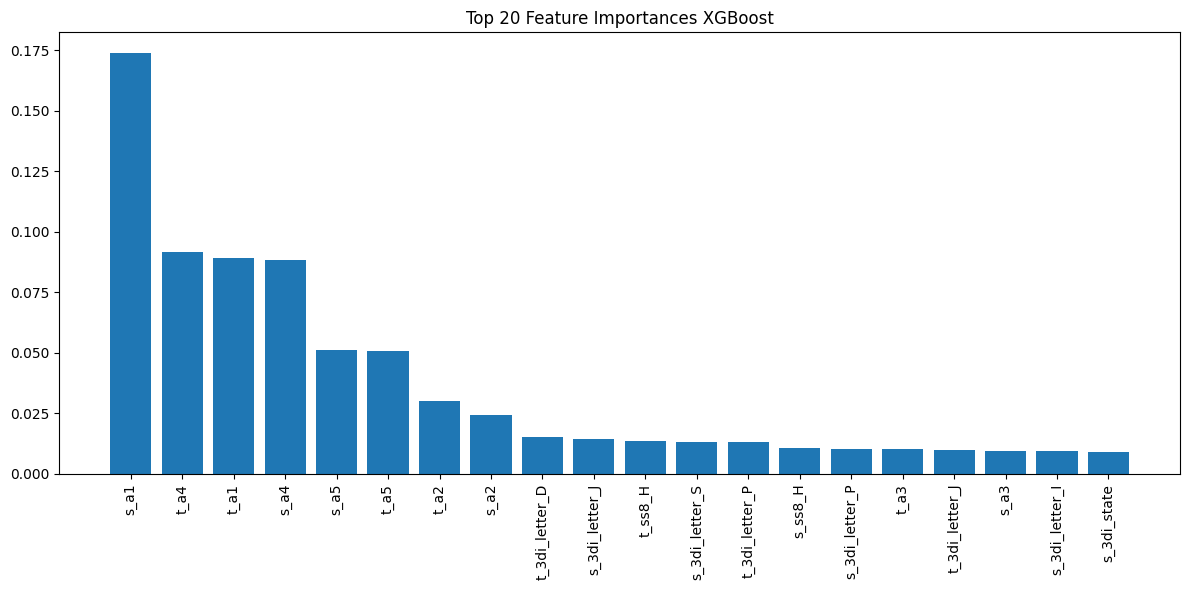

In [17]:

importances = np.mean([
    estimator.feature_importances_
    for estimator in rf.estimators_
], axis=0)

feature_names = X_train.columns.tolist()
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.title("Top 20 Feature Importances XGBoost")
plt.tight_layout()
plt.show()

In [14]:
label_prevalence = Y_val.mean().sort_values(ascending=False)

prevalence_rows = {"baseline": label_prevalence}
false_positive_counts = {}

Y_pred_tuned_df = pd.DataFrame(
    Y_pred_tuned,
    columns=Y_val.columns,
    index=Y_val.index
)

for class_idx, class_name in enumerate(label_cols):
    fp_mask = (Y_val.iloc[:, class_idx] == 0) & (Y_pred_tuned_df.iloc[:, class_idx] == 1)
    false_positives = Y_val.loc[fp_mask]

    n_fp = len(false_positives)
    false_positive_counts[class_name] = n_fp

    if n_fp == 0:
        print(f"\nNo false positives for {class_name}")
        continue
    false_positives_no_self = false_positives.drop(columns=[class_name])


    fp_label_prevalence = false_positives_no_self.mean()
    prevalence_rows[f"FP_{class_name}"] = fp_label_prevalence

fp_prevalence_df = pd.DataFrame(prevalence_rows).T
false_positive_counts = pd.Series(false_positive_counts, name="n_false_positives")

display(fp_prevalence_df)
print(false_positive_counts)


,HBOND,IONIC,PICATION,PIHBOND,PIPISTACK,SSBOND,VDW
baseline,0.722532,0.022796,0.006091,0.001184,0.025703,0.001666,0.513169
FP_HBOND,NaN,0.008843,0.015937,0.002673,0.012570,0.000257,0.979950
FP_VDW,0.967634,0.023391,0.006085,0.001170,0.030388,0.001287,NaN
FP_IONIC,0.860540,NaN,0.000000,0.000000,0.000000,0.000000,0.493787
FP_PIPISTACK,0.625954,0.000000,0.000000,0.000000,NaN,0.000000,0.556616
FP_PICATION,0.635492,0.000000,NaN,0.002398,0.000000,0.000000,0.630216
FP_SSBOND,0.522727,0.000000,0.000000,0.000000,0.000000,NaN,0.750000
FP_PIHBOND,0.526316,0.000000,0.073684,NaN,0.263158,0.000000,0.547368


HBOND        38902
VDW          85460
IONIC         4668
PIPISTACK     1572
PICATION      2085
SSBOND          44
PIHBOND         95
Name: n_false_positives, dtype: int64


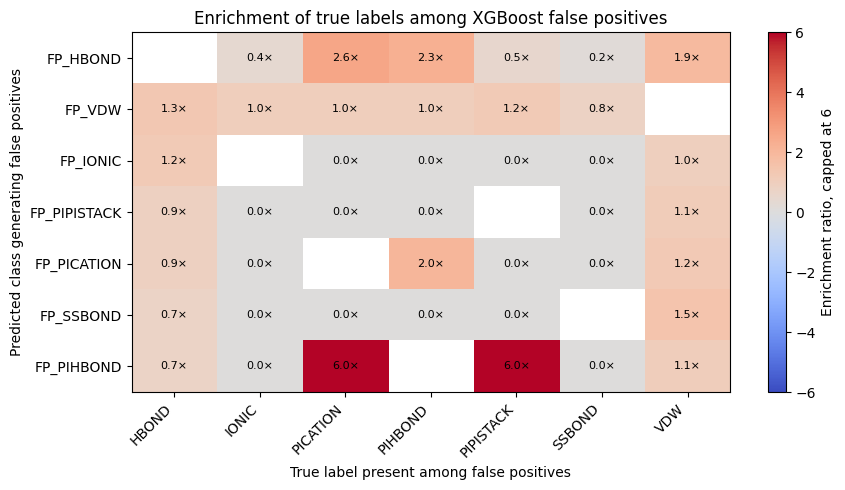

In [18]:
baseline = fp_prevalence_df.loc["baseline"]
fp_rows = fp_prevalence_df.drop(index="baseline")

enrichment_df = fp_rows.divide(baseline, axis=1)

plot_df = enrichment_df.clip(upper=6)

fig, ax = plt.subplots(figsize=(9, 5))

import matplotlib.colors as mcolors

vmax = np.nanmax(np.abs(plot_df.values))
vmin = -vmax
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

im = ax.imshow(plot_df, aspect="auto", cmap="coolwarm", norm=norm)

ax.set_xticks(np.arange(plot_df.shape[1]))
ax.set_yticks(np.arange(plot_df.shape[0]))
ax.set_xticklabels(plot_df.columns, rotation=45, ha="right")
ax.set_yticklabels(plot_df.index)

ax.set_xlabel("True label present among false positives")
ax.set_ylabel("Predicted class generating false positives")
ax.set_title("Enrichment of true labels among XGBoost false positives")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Enrichment ratio, capped at 6")

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.iloc[i, j]
        if not np.isnan(value):
            ax.text(j, i, f"{value:.1f}×", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


In [16]:
from sklearn.metrics import hamming_loss, accuracy_score

Y_prob_test = rf.predict_proba(X_test)
Y_prob_test_present = np.column_stack([prob[:, 1] for prob in Y_prob_test])
Y_pred_test = np.column_stack([
    (Y_prob_test_present[:, i] >= best_thresholds[label]).astype(int)
    for i, label in enumerate(label_cols)
])

print("=" * 60)
print("PER-CLASS RESULTS ON TEST SET (tuned thresholds)")
print("=" * 60)

for i, label in enumerate(label_cols):
    print(classification_report(
        Y_test.iloc[:, i],
        Y_pred_test[:, i],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1_test = f1_score(Y_test, Y_pred_test, average='macro', zero_division=0)
micro_f1_test = f1_score(Y_test, Y_pred_test, average='micro', zero_division=0)
hamming_test  = hamming_loss(Y_test, Y_pred_test)
subset_acc_test = accuracy_score(Y_test, Y_pred_test)

print(f"\nMacro F1:        {macro_f1_test:.4f}")
print(f"Micro F1:        {micro_f1_test:.4f}")
print(f"Hamming loss:    {hamming_test:.4f}")
print(f"Subset accuracy: {subset_acc_test:.4f}")


PER-CLASS RESULTS ON TEST SET (tuned thresholds)
              precision    recall  f1-score   support

      absent       0.70      0.28      0.40     59135
     present       0.78      0.95      0.86    157037

    accuracy                           0.77    216172
   macro avg       0.74      0.62      0.63    216172
weighted avg       0.76      0.77      0.73    216172

              precision    recall  f1-score   support

      absent       0.76      0.11      0.19    106333
     present       0.53      0.97      0.68    109839

    accuracy                           0.54    216172
   macro avg       0.64      0.54      0.43    216172
weighted avg       0.64      0.54      0.44    216172

              precision    recall  f1-score   support

      absent       0.99      0.98      0.99    210889
     present       0.45      0.80      0.58      5283

    accuracy                           0.97    216172
   macro avg       0.72      0.89      0.78    216172
weighted avg       0.98  

In [19]:
test_summary = pd.DataFrame({
    "label": label_cols,
    "support_test": Y_test.sum().values,
    "precision": [
        classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)['1']['precision']
        if '1' in classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)
        else np.nan
        for i in range(len(label_cols))
    ],
    "recall": [
        classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)['1']['recall']
        if '1' in classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)
        else np.nan
        for i in range(len(label_cols))
    ],
    "f1": [
        classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)['1']['f1-score']
        if '1' in classification_report(Y_test.iloc[:, i], Y_pred_test[:, i], output_dict=True, zero_division=0)
        else np.nan
        for i in range(len(label_cols))
    ],
}).sort_values("support_test", ascending=False)

display(test_summary)


,label,support_test,precision,recall,f1
0,HBOND,157037,0.777969,0.954750,0.857341
1,VDW,109839,0.527807,0.967543,0.683019
3,PIPISTACK,5530,0.752294,0.978662,0.850676
2,IONIC,5283,0.450707,0.802196,0.577148
4,PICATION,1367,0.299558,0.743965,0.427131
5,SSBOND,458,0.895178,0.932314,0.913369
6,PIHBOND,247,0.031496,0.016194,0.021390


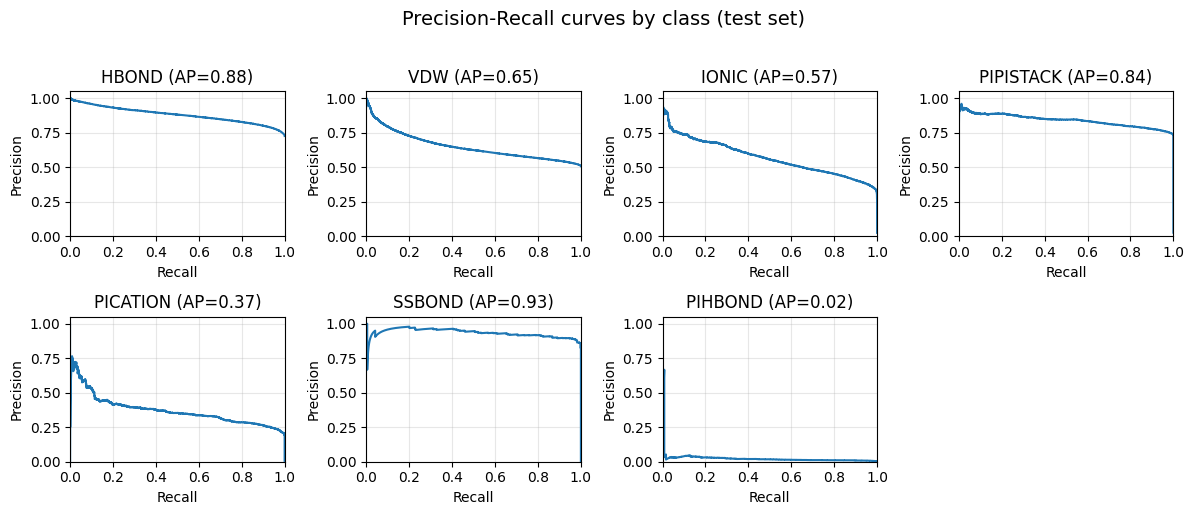

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

n_classes = len(label_cols)
n_cols = 4
n_rows = int(np.ceil(n_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.5 * n_rows))
axes = axes.flatten()

for i, label in enumerate(label_cols):
    precision, recall, _ = precision_recall_curve(Y_test.iloc[:, i], Y_prob_test_present[:, i])
    ap = average_precision_score(Y_test.iloc[:, i], Y_prob_test_present[:, i])

    ax = axes[i]
    ax.plot(recall, precision)
    ax.set_title(f"{label} (AP={ap:.2f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

for ax in axes[n_classes:]:
    ax.axis("off")

fig.suptitle("Precision-Recall curves by class (test set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [21]:
def predict_with_constraints_rf(model, X, X_names, thresholds):

    y_proba = model.predict_proba(X)
    proba_df = pd.DataFrame(
        np.column_stack([y_proba[i][:, 1] for i in range(len(label_cols))]),
        columns=label_cols,
        index=X.index
    )
    # Residue identities
    s_resn = X_names["s_resn"].str.upper()
    t_resn = X_names["t_resn"].str.upper()

    acidic    = {"D", "E"}            # Aspartate, Glutamate
    basic     = {"K", "R", "H"}       # Lysine, Arginine, Histidine
    aromatic  = {"F", "Y", "W", "H"}  # Phenylalanine, Tyrosine, Tryptophan, Histidine
    cysteine  = {"C"}                 # Cysteine
    ionic_possible = (
        (s_resn.isin(acidic) & t_resn.isin(basic)) |
        (t_resn.isin(acidic) & s_resn.isin(basic))
    )
    pipistack_possible = s_resn.isin(aromatic) & t_resn.isin(aromatic)
    pication_possible = (
        (s_resn.isin(aromatic) & t_resn.isin(basic)) |
        (t_resn.isin(aromatic) & s_resn.isin(basic))
    )
    ssbond_possible = s_resn.isin(cysteine) & t_resn.isin(cysteine)
    pihbond_possible = s_resn.isin(aromatic) | t_resn.isin(aromatic)
    proba_constrained_df = proba_df.copy()
    proba_constrained_df.loc[~ionic_possible, "IONIC"] = 0.0
    proba_constrained_df.loc[~pipistack_possible, "PIPISTACK"] = 0.0
    proba_constrained_df.loc[~pication_possible, "PICATION"] = 0.0
    proba_constrained_df.loc[~ssbond_possible, "SSBOND"] = 0.0
    proba_constrained_df.loc[~pihbond_possible, "PIHBOND"] = 0.0
    y_pred = pd.DataFrame(
        {label: (proba_constrained_df[label] >= thresholds[label]).astype(int)
         for label in label_cols},
        index=X.index
    )

    return y_pred, proba_constrained_df


In [22]:
X_val_names = val_df[["s_resn", "t_resn"]]

Y_pred_constrained_val, proba_constrained_val_df = predict_with_constraints_rf(
    rf, X_val, X_val_names, best_thresholds
)

constrained_classes = ["IONIC", "PIPISTACK", "PICATION", "SSBOND", "PIHBOND"]

print("=" * 60)
print("PER-CLASS RESULTS ON VALIDATION SET (with biological constraints)")
print("=" * 60)

for label in label_cols:
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_val[label],
        Y_pred_constrained_val[label],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1_constrained = f1_score(Y_val, Y_pred_constrained_val, average='macro', zero_division=0)
micro_f1_constrained = f1_score(Y_val, Y_pred_constrained_val, average='micro', zero_division=0)

print(f"\nMacro F1 (constrained): {macro_f1_constrained:.4f}   (tuned, unconstrained was {macro_f1_tuned:.4f})")
print(f"Micro F1 (constrained): {micro_f1_constrained:.4f}   (tuned, unconstrained was {micro_f1_tuned:.4f})")


PER-CLASS RESULTS ON VALIDATION SET (with biological constraints)

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.70      0.28      0.40     54116
     present       0.78      0.95      0.86    140919

    accuracy                           0.77    195035
   macro avg       0.74      0.62      0.63    195035
weighted avg       0.76      0.77      0.73    195035


--- VDW ---
              precision    recall  f1-score   support

      absent       0.75      0.10      0.18     94949
     present       0.53      0.97      0.69    100086

    accuracy                           0.55    195035
   macro avg       0.64      0.53      0.43    195035
weighted avg       0.64      0.55      0.44    195035


--- IONIC ---
              precision    recall  f1-score   support

      absent       1.00      0.98      0.99    190589
     present       0.43      0.80      0.56      4446

    accuracy                           0.97    195035
   macro avg       

In [23]:
rows = []
for label in label_cols:
    f1_baseline = f1_score(Y_val[label], Y_pred_tuned[:, label_cols.index(label)], zero_division=0)
    f1_constrained = f1_score(Y_val[label], Y_pred_constrained_val[label], zero_division=0)
    prec_baseline = precision_score(Y_val[label], Y_pred_tuned[:, label_cols.index(label)], zero_division=0)
    prec_constrained = precision_score(Y_val[label], Y_pred_constrained_val[label], zero_division=0)

    rows.append({
        "label": label,
        "constraint_applied": label in constrained_classes,
        "F1_baseline": f1_baseline,
        "F1_constrained": f1_constrained,
        "delta_F1": f1_constrained - f1_baseline,
        "precision_baseline": prec_baseline,
        "precision_constrained": prec_constrained,
        "delta_precision": prec_constrained - prec_baseline,
    })

constraint_comparison_df = pd.DataFrame(rows).round(4)
display(constraint_comparison_df)


,label,constraint_applied,F1_baseline,F1_constrained,delta_F1,precision_baseline,precision_constrained,delta_precision
0,HBOND,False,0.8559,0.8559,0.0,0.7757,0.7757,0.0
1,VDW,False,0.6863,0.6863,0.0,0.5315,0.5315,0.0
2,IONIC,True,0.5612,0.5612,0.0,0.4323,0.4323,0.0
3,PIPISTACK,True,0.8525,0.8525,0.0,0.7568,0.7568,0.0
4,PICATION,True,0.4234,0.4234,0.0,0.2966,0.2966,0.0
5,SSBOND,True,0.9050,0.9050,0.0,0.8739,0.8739,0.0
6,PIHBOND,True,0.0767,0.0767,0.0,0.1204,0.1204,0.0


In [24]:
X_test_names = test_df[["s_resn", "t_resn"]]

Y_pred_constrained_test, proba_constrained_test_df = predict_with_constraints_rf(
    rf, X_test, X_test_names, best_thresholds
)

print("=" * 60)
print("PER-CLASS RESULTS ON TEST SET (with biological constraints)")
print("=" * 60)

for label in label_cols:
    print(f"\n--- {label} ---")
    print(classification_report(
        Y_test[label],
        Y_pred_constrained_test[label],
        target_names=['absent', 'present'],
        zero_division=0
    ))

macro_f1_constrained_test = f1_score(Y_test, Y_pred_constrained_test, average='macro', zero_division=0)
micro_f1_constrained_test = f1_score(Y_test, Y_pred_constrained_test, average='micro', zero_division=0)

print(f"\nMacro F1 (constrained, test): {macro_f1_constrained_test:.4f}   (unconstrained was {macro_f1_test:.4f})")
print(f"Micro F1 (constrained, test): {micro_f1_constrained_test:.4f}   (unconstrained was {micro_f1_test:.4f})")


PER-CLASS RESULTS ON TEST SET (with biological constraints)

--- HBOND ---
              precision    recall  f1-score   support

      absent       0.70      0.28      0.40     59135
     present       0.78      0.95      0.86    157037

    accuracy                           0.77    216172
   macro avg       0.74      0.62      0.63    216172
weighted avg       0.76      0.77      0.73    216172


--- VDW ---
              precision    recall  f1-score   support

      absent       0.76      0.11      0.19    106333
     present       0.53      0.97      0.68    109839

    accuracy                           0.54    216172
   macro avg       0.64      0.54      0.43    216172
weighted avg       0.64      0.54      0.44    216172


--- IONIC ---
              precision    recall  f1-score   support

      absent       0.99      0.98      0.99    210889
     present       0.45      0.80      0.58      5283

    accuracy                           0.97    216172
   macro avg       0.72  

In [25]:
import os
import pickle
from sklearn.metrics import (
    matthews_corrcoef,
    balanced_accuracy_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    roc_auc_score
)

os.makedirs("classification_ring/models/xgboost/", exist_ok=True)

model_path = "classification_ring/models/xgboost/xgb_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(rf, f)
print(f"Model saved to {model_path}")


Model saved to /content/drive/MyDrive/SB/SB_Project/classification_ring/models/xgboost/xgb_model.pkl


In [26]:
def compute_threshold_and_curve_results(y_scores, Y_true, target_names):
    thresholds = np.arange(0.00, 1.01, 0.01)

    threshold_results = []
    curve_results = []

    for class_idx, class_name in enumerate(target_names):

        y_true = Y_true.iloc[:, class_idx].values
        y_score = y_scores[:, class_idx]

        for threshold in thresholds:
            y_pred = (y_score >= threshold).astype(int)
            threshold_results.append({
                "class": class_name,
                "threshold": threshold,
                "MCC": matthews_corrcoef(y_true, y_pred),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
            })

        precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
        fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        auc = roc_auc_score(y_true, y_score)

        curve_results.append({
            "class": class_name,
            "precision": precision,
            "recall": recall,
            "pr_thresholds": pr_thresholds,
            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,
            "average_precision": ap,
            "ROC_AUC": auc
        })

    return pd.DataFrame(threshold_results), pd.DataFrame(curve_results)


print("Helper defined.")


Helper defined.


In [27]:

threshold_results_df, curve_results_df = compute_threshold_and_curve_results(
    Y_prob_present, Y_val, label_cols
)

threshold_results_df.to_parquet(
    "classification_ring/models/xgboost/threshold_results.parquet", index=False
)
curve_results_df.to_parquet(
    "classification_ring/models/xgboost/curve_results.parquet", index=False
)
print("Baseline metrics saved.")


Baseline metrics saved.


In [28]:

postprocessed_threshold_results_df, postprocessed_curve_results_df = compute_threshold_and_curve_results(
    proba_constrained_val_df.values, Y_val, label_cols
)

postprocessed_threshold_results_df.to_parquet(
    "classification_ring/models/xgboost/postprocessed_threshold_results.parquet", index=False
)
postprocessed_curve_results_df.to_parquet(
    "classification_ring/models/xgboost/postprocessed_curve_results.parquet", index=False
)
print("Post-processed metrics saved.")


Post-processed metrics saved.
